# NLP - Visualizing Embeddings

In [1]:
# We are supposed to reduce dimension from 100D -> 2D
# This will let us visually see:
# 1. similar words clustered together
# 2. Opposite words separate

# How we are going to reduce Dimensions ?
"""
We will use Dimensionality Reduction:
- Reducing the number of features while preserving important information
We convert:
10000 -> 100
100 -> 10

Why we need to do that?
To solve problem of Curse of Dimensionality

Types of Dimensionality Reduction
1. Feature Selection: Remove some useless columns
2. Feature Extraction: Create new feature from existing columns

PCA - Combine features
- finds the direction where data varies most
- these directions = Principal Components
Instead of original features - we use these directions

Suppose user:
height and weight are correlated
Instead of 2 features - PCA creates 1 new feature representing both

How PCA works?
1. Standardize data
2. Compute covariance matrix
3. Find eigenvectors
4. Select top components
5. Project data

Suppose we want 2 components:
PC1 -> most information - 60%
PC2 -> second most - 25%

Limitation of PCA:
1. Linear only
2. Cannot capture comples shapes

T-SNE - t-distributed Stochastic Neighbor Embedding
It preserve:
Local structure (neighbors)
Points close in high-dim -> close in low-dim
It converts distance -> probabilities
Use KL Divergence


UMAP - Uniform Manifold Approximation & Projection
"""

'\nWe will use Dimensionality Reduction:\n- Reducing the number of features while preserving important information\nWe convert:\n10000 -> 100\n100 -> 10\n\nWhy we need to do that?\nTo solve problem of Curse of Dimensionality\n\nTypes of Dimensionality Reduction\n1. Feature Selection: Remove some useless columns\n2. Feature Extraction: Create new feature from existing columns\n\nPCA - Combine features\n- finds the direction where data varies most\n- these directions = Principal Components\nInstead of original features - we use these directions\n\nSuppose user:\nheight and weight are correlated\nInstead of 2 features - PCA creates 1 new feature representing both\n\nHow PCA works?\n1. Standardize data\n2. Compute covariance matrix\n3. Find eigenvectors\n4. Select top components\n5. Project data\n\nSuppose we want 2 components:\nPC1 -> most information - 60%\nPC2 -> second most - 25%\n\nLimitation of PCA:\n1. Linear only\n2. Cannot capture comples shapes\n\nT-SNE - t-distributed Stochastic

In [2]:
import gensim.downloader as api
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [3]:
model = api.load("glove-wiki-gigaword-100")
print("Loaded...")

Loaded...


In [4]:
words = [
    "king","queen", "man", "woman",
    "dog", "cat", "animal",
    "car","truck","bus","vehicle",
    "happy","sad","joy","anger"
]

In [5]:
vectors = [model[word] for word in words]

In [6]:
vectors[0].shape

(100,)

In [7]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

In [8]:
reduced.shape

(15, 2)

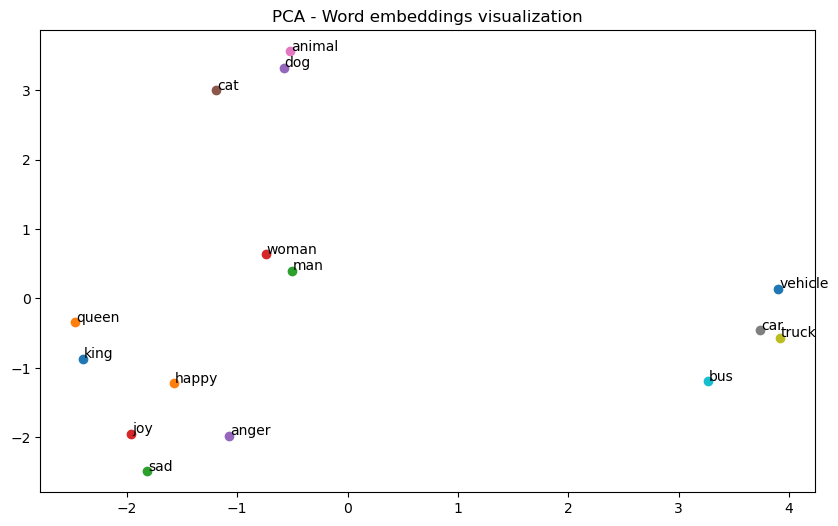

In [9]:
plt.figure(figsize=(10,6))

for i, word in enumerate(words):
    x = reduced[i][0]
    y = reduced[i][1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)

plt.title("PCA - Word embeddings visualization")
plt.show()

In [11]:
from sklearn.manifold import TSNE
import numpy as np

In [12]:
vectors = np.array([model[word] for word in words])

In [16]:
tsne = TSNE(n_components=2, perplexity=2)
reduced = tsne.fit_transform(vectors)

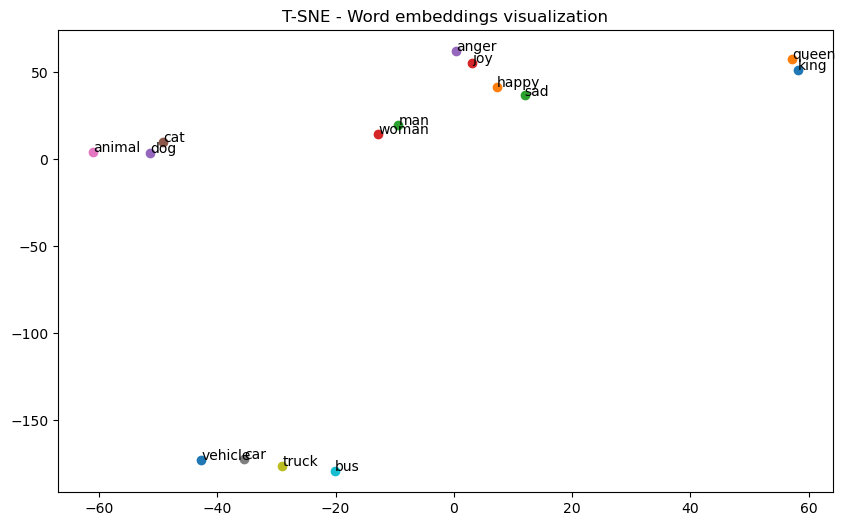

In [17]:
plt.figure(figsize=(10,6))

for i, word in enumerate(words):
    x = reduced[i][0]
    y = reduced[i][1]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word)

plt.title("T-SNE - Word embeddings visualization")
plt.show()